<a href="https://colab.research.google.com/github/amandammt17/puc-rioMVPs/blob/main/An%C3%A1lise_Explorat%C3%B3ria_e_Pr%C3%A9_processamento_do_E_Commerce_Sales_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Amanda da Motta Matinha Teixeira

**Matrícula:** 4052026000442

**Dataset:** [E-Commerce Sales Dataset](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/data)



# Descrição do Problema

O E-Commerce Sales Dataset é um conjunto de dados multivariado que oferece uma visão detalhada das vendas de e-commerce de vestuário feminino na Índia. Ele contém dados sobre vendas na plataforma da Amazon, incluindo informações sobre o produto, local e modo de entrega. O objetivo principal deste MVP é explorar esses dados para extrair insights acionáveis e, futuramente, criar um modelo que preveja demandas futuras.



## Hipóteses do Problema

As hipóteses traçadas são as seguintes:

1. **A categoria de produtos mais vendidos é o sari (saree)?**

2. **Os maiores pedidos são feitos por empresas (vendas B2B)?**

3. **O cancelamento dos pedidos está relacionado com o método de entrega?**

## Tipo de Problema

Este é um problema de regressão, que pertence à classe de **aprendizado supervisionado**. Dado um histórico de vendas, o objetivo é prever a quantidade de vendas futuras.

## Seleção de Dados

O dataset possui um histórico de pedidos de 31 de março de 2022 a 29 de junho de 2022. Para realizar uma análise mês a mês, convêm excluir os pedidos de março, pois a amostra é insuficiente para representar o comportamento mensal. A exclusão será feita na etapa de Limpeza dos Dados.


## Atributos do Dataset

O dataset contém 128.975 amostras e possui 24 atributos:

- ***index*** (coluna índice)
- ***Order ID*** (id do pedido)
- ***Date*** (data da venda)
- ***Status*** (status da venda)
- ***Fulfilment*** (método de envio - Amazon ou Merchant)
- ***Sales Channel*** (canal de venda - Amazon.in ou non-Amazon)
- ***ship-service-level*** (método de entrega - Standard ou Expedited)
- ***Style*** (estilo do produto)
- ***SKU*** (unidade de manutenção de estoque)
- ***Category*** (tipo de produto)
- ***Size*** (tamanho do produto)
- ***ASIN*** (número de identificação padrão da Amazon)
- ***Courier Status*** (status da transportadora)
- ***Qty*** (quantidade do produto)
- ***currency*** (moeda utilizada para a venda)
- ***Amount*** (valor da venda)
- ***ship-city*** (cidade do endereço de entrega)
- ***ship-state*** (UF do endereço de entrega)
- ***ship-postal-code*** (CEP do endereço de entrega)
- ***ship-country*** (país do endereço de entrega)
- ***promotion-ids*** (identificação de promoções)
- ***B2B*** (venda de empresa para empresa - Business to Business)
- ***fulfilled-by*** (empresa responsável pela entrega)
- ***Unnamed: 22*** (coluna sem nome e sem valores)


Alguns desses atributos não acrescentam valor ao dataset ou são redundantes, a limpeza será realizada na próxima seção.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [866]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder


In [867]:
# carregamento do dataset
url = "https://raw.githubusercontent.com/amandammt17/puc-rioMVPs/refs/heads/main/Amazon%20Sale%20Report.csv"

sales = pd.read_csv(url)


In [868]:
# guardando o dataset em um dataframe
df = pd.DataFrame(sales)

# Análise de Dados


## Total e Tipo das Instâncias

Conforme dito anteriormente, o dataset original possui 128.975 instâncias e 24 atributos. Ele possui um atributo booleano (coluna B2B), quatro numéricos (index, Qty, Amount e ship-postal-code), enquanto os outros são do tipo object.

In [869]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
df.info()

Total de instâncias: 128975

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 n

Serão feitas agora alterações em tipos de dados de alguns atributos.

In [870]:
#converter o tipo de dados da coluna Date para datetime
df['Date'] = df['Date'].astype('datetime64[s]')

#converter o tipo de dados da coluna ship-postal-code para string
df['ship-postal-code'] = df['ship-postal-code'].astype('Int64').astype(str)

#converter o tipo de dados da coluna B2B para int
df['B2B'] = df['B2B'].astype(np.int8)

#confirmar a mudança de tipo de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype        
---  ------              --------------   -----        
 0   index               128975 non-null  int64        
 1   Order ID            128975 non-null  object       
 2   Date                128975 non-null  datetime64[s]
 3   Status              128975 non-null  object       
 4   Fulfilment          128975 non-null  object       
 5   Sales Channel       128975 non-null  object       
 6   ship-service-level  128975 non-null  object       
 7   Style               128975 non-null  object       
 8   SKU                 128975 non-null  object       
 9   Category            128975 non-null  object       
 10  Size                128975 non-null  object       
 11  ASIN                128975 non-null  object       
 12  Courier Status      122103 non-null  object       
 13  Qty                 128975 non-null  int64  

Serão exibidos os valores máximos e mínimos para o atributo data, a fim de comprovar o que foi dito na seção Seleção de Dados.

In [871]:
#exibir menor valor da coluna Date
print(f"Data mais antiga: {df['Date'].min()}")

#exibir maior valor da coluna Date
print(f"Data mais recente: {df['Date'].max()}")


Data mais antiga: 2022-03-31 00:00:00
Data mais recente: 2022-06-29 00:00:00


Tendo confirmado que o histórico de datas do dataset começa em 31 de março, essas instâncias serão desconsideradas do dataset.

In [872]:
#considerar no dataset somente as instâncias onde a data seja maior que 31 de março de 2022
df = df[df['Date'] > '2022-03-31']

#exibir o novo menor valor da coluna Date
print(f"Data mais antiga: {df['Date'].min()}")

#exibir maior valor da coluna Date
print(f"Data mais recente: {df['Date'].max()}")

Data mais antiga: 2022-04-01 00:00:00
Data mais recente: 2022-06-29 00:00:00


Visualizando as primeiras instâncias do dataset:


In [873]:
#primeiras linhas
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,NaN,0,Easy Ship,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085,IN,Amazon PLCC Free-Financing Universal Merchant ...,0,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,1,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,NaN,0,Easy Ship,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,NaN,0,NaN,NaN


Visualizando as últimas instâncias do dataset:


In [874]:
#últimas linhas
df.tail()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
128970,128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,INR,517.0,HYDERABAD,TELANGANA,500013,IN,NaN,0,NaN,False
128971,128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,...,INR,999.0,GURUGRAM,HARYANA,122004,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,0,NaN,False
128972,128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,...,INR,690.0,HYDERABAD,TELANGANA,500049,IN,NaN,0,NaN,False
128973,128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,...,INR,1199.0,Halol,Gujarat,389350,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,0,NaN,False
128974,128974,408-7436540-8728312,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003-SET-S,Set,...,INR,696.0,Raipur,CHHATTISGARH,492014,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,0,NaN,False


Percebe-se que o alguns atributos do dataset não trazem informações relevantes, já que os valores da coluna index são idênticos ao index nativo do DataFrame e mais de 60% dos valores da colunas promotion-ids e Unnamed:22 são nulos. Além disso, as colunas SKU e ASIN possuem códigos que só são compreensíveis para os sistemas da Amazon. Esses atributos serão, portanto, retirados do dataset.

In [875]:
#excluir colunas
df = df.drop(['index','SKU','ASIN', 'promotion-ids','Unnamed: 22'], axis=1, errors='ignore')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128804 entries, 0 to 128974
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype        
---  ------              --------------   -----        
 0   Order ID            128804 non-null  object       
 1   Date                128804 non-null  datetime64[s]
 2   Status              128804 non-null  object       
 3   Fulfilment          128804 non-null  object       
 4   Sales Channel       128804 non-null  object       
 5   ship-service-level  128804 non-null  object       
 6   Style               128804 non-null  object       
 7   Category            128804 non-null  object       
 8   Size                128804 non-null  object       
 9   Courier Status      121938 non-null  object       
 10  Qty                 128804 non-null  int64        
 11  currency            121018 non-null  object       
 12  Amount              121018 non-null  float64      
 13  ship-city           128771 non-null  object      

Depois destas tranformações, o dataset possui 128.804 instâncias e 19 atributos.

In [876]:
#formato do dataset
df.shape

(128804, 19)

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [877]:
# estatísticas descritivas básicas do dataset
df.describe()

,Date,Qty,Amount,B2B
count,128804,128804.000000,121018.000000,128804.000000
mean,2022-05-12 13:10:42,0.904421,648.589420,0.006762
min,2022-04-01 00:00:00,0.000000,0.000000,0.000000
25%,2022-04-20 00:00:00,1.000000,449.000000,0.000000
50%,2022-05-10 00:00:00,1.000000,605.000000,0.000000
75%,2022-06-04 00:00:00,1.000000,788.000000,0.000000
max,2022-06-29 00:00:00,15.000000,5584.000000,1.000000
std,NaN,0.313392,281.240536,0.081954


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [878]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
Date,2022-05-12 13:10:42
Qty,0.904421
Amount,648.58942
B2B,0.006762


Já pode-se notar que o atributo 'Qty' possui uma porcentagem considerável de valores zero, o suficiente para trazer a sua média para menos de 1. Além disso, a proporção entre vendas B2B e não-B2B (B2C) está desbalanceado, dado que a média do atributo 'B2B' está tão próximo de zero.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [879]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
Date,NaN
Qty,0.313392
Amount,281.240536
B2B,0.081954


De acordo com as observações feitas acima, conclui-se que os valores dos atributos 'Qty' e 'B2B' se concentram perto das suas médias, enquanto os valores do atributo 'Amount' está mais disperso.

### Moda

A moda é a medida de tendência central que representa o valor que mais se repete em um conjunto de dados. Em termos estatísticos, é o valor com a maior frequência absoluta. Pode ser usada para dados descritivos e qualitativos.

In [880]:
df.mode()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,171-5057375-2831560,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,JNE3797,Set,M,Shipped,1.0,INR,399.0,BENGALURU,MAHARASHTRA,201301,IN,0.0,Easy Ship
1,403-4984515-8861958,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ao analisar os valores acima, pode-se afirmar que os status mais comuns dos pedidos são 'Shipped' (enviados), a categoria de produto mais comum é 'Set' e seu tamanho é 'M'.

## Tratamento de Valores Nulos

Como é mostrado abaixo, existem alguns atributos com valores nulos no dataset. Será feita a análise de cada um dos atributos e a decisão de como tratar cada um deles adiante.

In [881]:
# verificar a quantidades de valores nulos em cada atributo
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
Category,0
Size,0
Courier Status,6866


### Atributo Courier Status




In [882]:
#exibir os possíveis valores do atributo analisado
df.groupby('Courier Status').size()

,0
Courier Status,
Cancelled,5926
Shipped,109335
Unshipped,6677


In [883]:
#exibir as instâncias onde o atributo é nulo
df_cs = df[df['Courier Status'].isnull()]
df_cs

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,0,Easy Ship
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,0,Easy Ship
23,404-6019946-2909948,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET291,Set,M,NaN,0,INR,570.48,pune,MAHARASHTRA,411044,IN,0,Easy Ship
29,404-5933402-8801952,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,JNE2132,kurta,3XL,NaN,0,NaN,NaN,GUWAHATI,ASSAM,781003,IN,0,Easy Ship
83,404-6522553-9345930,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET377,Set,M,NaN,0,INR,1105.36,DEHRADUN,UTTARAKHAND,248001,IN,0,Easy Ship
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128762,402-4651401-6366769,2022-06-01,Cancelled,Merchant,Amazon.in,Standard,J0184,kurta,S,NaN,0,INR,385.71,BENGALURU,KARNATAKA,560043,IN,0,Easy Ship
128808,408-4182027-2307535,2022-06-01,Cancelled,Merchant,Amazon.in,Standard,JNE3619,kurta,S,NaN,0,NaN,NaN,BENGALURU,KARNATAKA,560092,IN,0,Easy Ship
128855,402-1958677-2521967,2022-06-01,Cancelled,Merchant,Amazon.in,Standard,JNE3568,kurta,M,NaN,0,NaN,NaN,Cherukunnu (p.o),KERALA,670301,IN,0,Easy Ship
128875,403-9524128-9243508,2022-06-01,Cancelled,Merchant,Amazon.in,Standard,JNE3797,Western Dress,XL,NaN,0,INR,734.29,Barabanki,UTTAR PRADESH,225001,IN,0,Easy Ship


Analisando as instâncias acima, é possível inferir que os valores nulos de 'Courier Status' acontecem quando o atributo 'Status' é igual ao valor 'Cancelled'. Essa hipótese será verificada agora, ao inspecionar todos os possíveis valores do atributo 'Status' quando 'Courier Status' for nulo.

In [884]:
#exibir os valores do atributo 'Status' quando 'Courier Status' for nulo, e sua frequência
df_cs.groupby('Status').size()

,0
Status,
Cancelled,6855
Shipped - Delivered to Buyer,8
Shipped - Returned to Seller,3


Percebe-se que, em 99,8% das vezes que o atributo 'Courier Status' é nulo, o valor do atributo 'Status' é 'Cancelled' e nos 0,2% restantes, o valor é 'Shipped'. É possível então atribuir esses valores ao atributo 'Courier Status'.

In [885]:
#localiza as instâncias onde 'Courier Status' é nulo e o valor de 'Status' é igual a 'Cancelled' e atribui este valor a 'Courier Status'
df.loc[(df['Courier Status'].isnull()) & (df['Status'] == 'Cancelled'), 'Courier Status'] = 'Cancelled'

#localiza as outras instâncias onde 'Courier Status' é nulo e atribui o valor 'Shipped' a 'Courier Status'
df.loc[df['Courier Status'].isnull(), 'Courier Status'] = 'Shipped'

#verifica se restou algum valor nulo em 'Courier Status'
print("Valores nulos em 'Courier Status': ", df['Courier Status'].isnull().sum())


Valores nulos em 'Courier Status':  0


### Atributo currency


In [886]:
#exibir os possíveis valores do atributo analisado
df.groupby('currency').size()

,0
currency,
INR,121018


Como visto acima, o atributo currency só possui um valor possível, 'INR', que é o código da moeda indiana, a rúpia. Então, na prática, este atributo não oferece nenhuma informação relevante para o modelo e, a fim de simplificar o dataset, o atributo será excluído.

In [887]:
#excluir coluna
df = df.drop('currency', axis=1, errors='ignore')


### Atributo Amount

Como este atributo é numérico, os valores nulos serão substituídos pela média calculada na seção de Estatísticas Descritivas. A média foi escolhido por possuir a propriedade de não modificar as características descritivas do dataset.

In [888]:
#exibe a média do atributo 'Amount' antes do tratamento de nulos
print("Média de 'Amount' antes do tratamento: ", df['Amount'].mean())

#localiza as instâncias onde 'Amount' é nulo e atribui a sua média a ele'
df.loc[df['Amount'].isnull(), 'Amount'] = df['Amount'].mean()

#verifica se restou algum valor nulo em 'Amount'
print("\nValores nulos em 'Amount': ", df['Amount'].isnull().sum())

#exibe a média do atributo 'Amount' depois do tratamento de nulos
print("\nMédia de 'Amount' depois do tratamento: ", df['Amount'].mean())

Média de 'Amount' antes do tratamento:  648.5894201689006

Valores nulos em 'Amount':  0

Média de 'Amount' depois do tratamento:  648.5894201689006


### Atributos ship-city, ship-estate e ship-country

In [889]:
#exibir as instâncias onde o atributo é nulo
df[df['ship-city'].isnull()]


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
1871,404-0566904-4825137,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,J0301,Top,L,Shipped,1,493.00000,NaN,NaN,<NA>,NaN,0,NaN
1872,404-0566904-4825137,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,JNE3697,kurta,L,Shipped,1,458.00000,NaN,NaN,<NA>,NaN,0,NaN
8752,406-4003386-8768363,2022-04-25,Shipped,Amazon,Amazon.in,Expedited,JNE3376,kurta,M,Shipped,1,432.00000,NaN,NaN,<NA>,NaN,0,NaN
11215,402-0107720-7057168,2022-04-23,Shipped,Amazon,Amazon.in,Expedited,J0003,Set,S,Shipped,1,654.00000,NaN,NaN,<NA>,NaN,0,NaN
13252,407-4532637-8415521,2022-04-22,Cancelled,Merchant,Amazon.in,Standard,JNE3405,kurta,S,Cancelled,0,380.00000,NaN,NaN,<NA>,NaN,0,Easy Ship
15688,404-9229894-8608305,2022-04-21,Shipped,Amazon,Amazon.in,Expedited,JNE3510,kurta,M,Shipped,1,442.00000,NaN,NaN,<NA>,NaN,0,NaN
16787,402-4919636-4333150,2022-04-20,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE1233,kurta,3XL,Shipped,1,376.00000,NaN,NaN,<NA>,NaN,0,Easy Ship
18351,405-4927647-8064368,2022-04-19,Shipped,Amazon,Amazon.in,Expedited,J0230,Set,XS,Shipped,1,1112.00000,NaN,NaN,<NA>,NaN,0,NaN
22930,402-8628677-0457954,2022-04-16,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,J0003,Set,S,Shipped,1,654.00000,NaN,NaN,<NA>,NaN,0,Easy Ship
24986,406-4079063-8291520,2022-04-15,Cancelled,Amazon,Amazon.in,Expedited,JNE3567,kurta,XXL,Unshipped,1,399.00000,NaN,NaN,<NA>,NaN,0,NaN


Como se pode observar, em todas as instâncias onde 'ship-postal-code' é nulo, os outros atributos relacionados à localização também são nulos. Como o número de instâncias onde isso ocorre é muito pequeno em relação ao tamanho total do dataset, foi escolhida a exclusão destas linhas como o método de tratamento de nulos para estes atributos.

In [890]:
#excluir linhas onde os atributos 'ship-city', 'ship-state', 'ship-country' sejam nulos
df = df.dropna(subset=['ship-city', 'ship-state', 'ship-country'])

### Atributo fulfilled-by



In [891]:
#exibir os possíveis valores do atributo analisado
df.groupby('fulfilled-by').size()

,0
fulfilled-by,
Easy Ship,39241


In [892]:
#exibir os possíveis valores do atributo 'Fulfilment'
df.groupby('Fulfilment').size()

,0
Fulfilment,
Amazon,89530
Merchant,39241


Dado que o atributo 'fulfilled-by' é composto de 39.241 instâncias do valor 'Easy Ship' e 89.530 valores nulos e o atributo 'Fulfilment' é composto de 39.241 instâncias do valor 'Merchant' e 89.530 instâncias do valor 'Amazon', é possível induzir que existe uma relação entre os atributos. A ser confirmado abaixo:

In [893]:
#exibir os possíveis valores do atributo 'Fulfilment' quando o atributo 'fulfilled-by' for igual a 'Easy Ship'
df[df['fulfilled-by'] == 'Easy Ship'].groupby('Fulfilment').size()

,0
Fulfilment,
Merchant,39241


Como proposto, ficou comprovado que todas as instâncias do atributo 'fulfilled-by' que não são nulas, possuem o valor 'Merchant' no atributo 'Fulfilment'. Logo, as instâncias nulas de 'fulfilled-by' estão relacionadas com o outro valor de 'Fulfilment', 'Amazon'.

Infere-se que o atributo 'fulfilled-by' foi criado para indicar o nome da empresa terceirizada que fará a entrega do pedido. E no período de tempo que este dataset explora, só foi contratada uma empresa terceirizada para realizar as entregas ('Easy Ship'). Quando não é esta empresa que entrega os pedidos, é a própria Amazon que as faz.

Para simplificar ainda mais o dataset, os valores nulos de 'fulfilled-by' serão trocados por Amazon e o atributo 'Fulfilment' será desconsiderado.

In [894]:
#trocar os valores nulos de 'fulfilled-by' por 'Amazon'
values = {'fulfilled-by': 'Amazon'}
df = df.fillna(value=values)

#excluir coluna 'Fulfilment'
df = df.drop('Fulfilment', axis=1, errors='ignore')

#exibir os possíveis valores do atributo analisado
df.groupby('fulfilled-by').size()


,0
fulfilled-by,
Amazon,89530
Easy Ship,39241


In [895]:
#verificar a quantidades de valores nulos em cada atributo
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128771 entries, 0 to 128974
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype        
---  ------              --------------   -----        
 0   Order ID            128771 non-null  object       
 1   Date                128771 non-null  datetime64[s]
 2   Status              128771 non-null  object       
 3   Sales Channel       128771 non-null  object       
 4   ship-service-level  128771 non-null  object       
 5   Style               128771 non-null  object       
 6   Category            128771 non-null  object       
 7   Size                128771 non-null  object       
 8   Courier Status      128771 non-null  object       
 9   Qty                 128771 non-null  int64        
 10  Amount              128771 non-null  float64      
 11  ship-city           128771 non-null  object       
 12  ship-state          128771 non-null  object       
 13  ship-postal-code    128771 non-null  object      

Dataset possui agora 128.771 instâncias e 17 atributos.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### Data *(Date)*
Refere-se à data de determinado pedido.

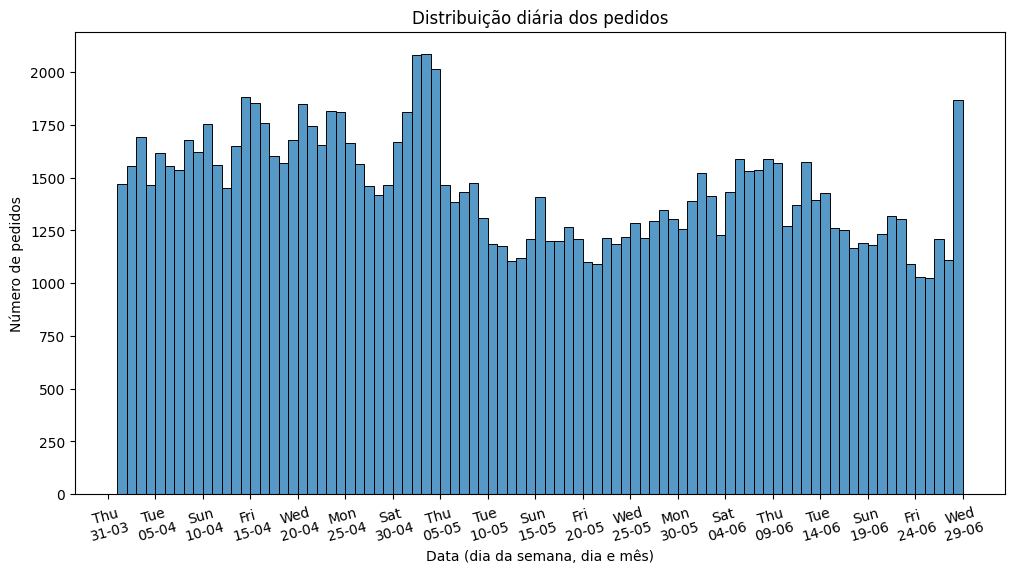

In [896]:
plt.figure(figsize=(12, 6))
# Histograma do atributo Date
ax = sns.histplot(df['Date'], binwidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d-%m'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.title('Distribuição diária dos pedidos')
plt.xlabel('Data (dia da semana, dia e mês)')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=15)
plt.show()

O histograma mostra a distribuição das datas contidas no dataset, onde cada bin do histograma representa exatamente 1 dia. Pode-se observar que não existe nenhuma data faltante no intervado e que o dataset possui uma quantidade de instâncias considerável por dia. Observa-se também um pico de pedidos nos primeiros dias de maio e no último dia do intervado, dia 26 de junho.

### Quantidade *(Qty)*
Refere-se à quantidade de determinado produto em determinado pedido.

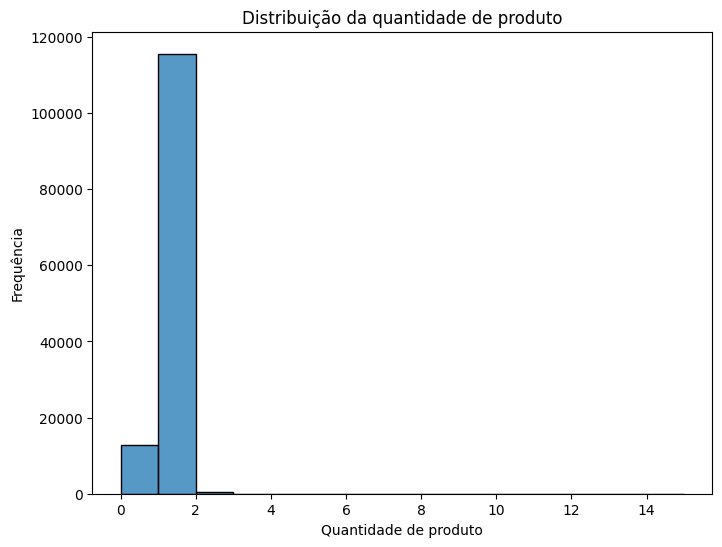

In [897]:
plt.figure(figsize=(8, 6))
# Histograma do atributo Qty
ax = sns.histplot(df['Qty'], binwidth=1)
plt.title('Distribuição da quantidade de produto')
plt.xlabel('Quantidade de produto')
plt.ylabel('Frequência')
plt.show()

O que mais chama atenção neste histograma é a desproporcionalidade entre a frequência das amostras. De 128 mil instâncias, mais de 115 mil tem o atributo igual a 1. Além disso, novamente percebe-se uma quantidade significativa de pedidos com sua quantidade de produtos zerada.

### Valor Total *(Amount)*

Refere-se ao valor total (quantidade * valor único) de determinado produto em determinado pedido.

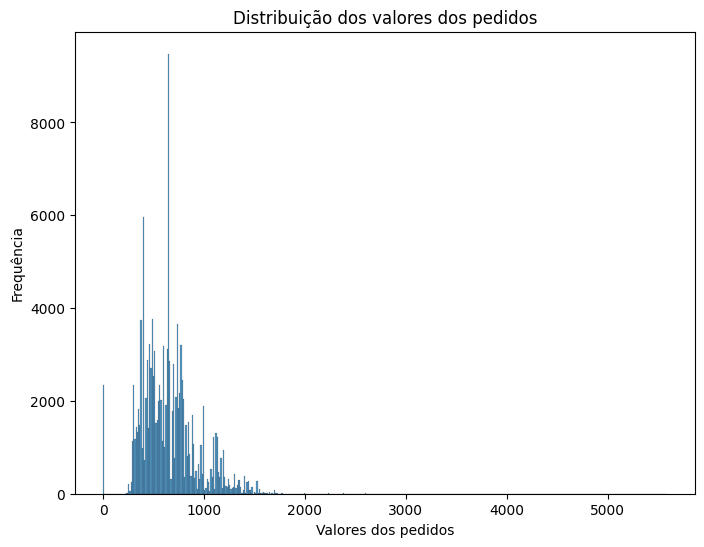

In [898]:
plt.figure(figsize=(8, 6))
# Histograma do atributo Amount
ax = sns.histplot(df['Amount'])
plt.title('Distribuição dos valores dos pedidos')
plt.xlabel('Valores dos pedidos')
plt.ylabel('Frequência')
plt.show()

Observa-se que o valor total dos pedidos estão concentrados entre 300 e 1.500 rúpias, sendo que pelo menos dois valores se repetem bastante (os picos do histograma). Pode-se notar também uma concentração considerável de amostras com o valor zero e algumas poucas amostras com valor entre 1.500 e 5.000 rúpias.

### Tipo de Venda *(B2B)*

Refere-se ao tipo de venda de determinado pedido. Se for B2B *(business to business)*, o valor é 1. Caso contrário, o valor é 0.

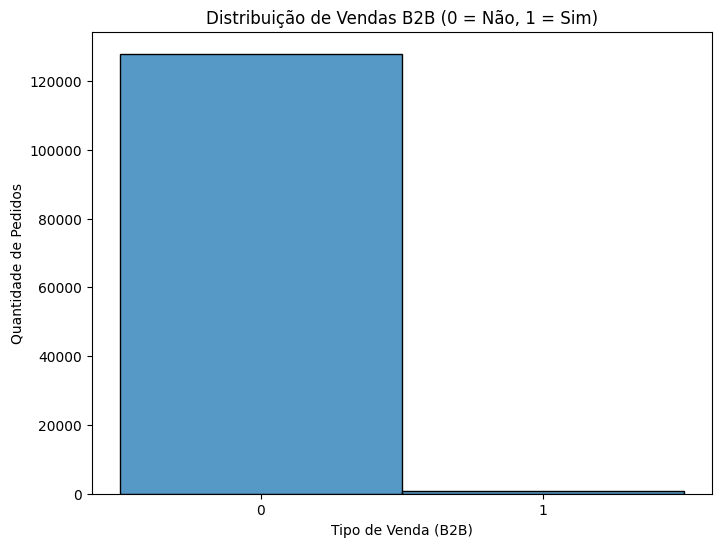

In [899]:
plt.figure(figsize=(8, 6))
# Histograma do atributo B2B
ax = sns.histplot(df['B2B'], discrete=True)
plt.title('Distribuição de Vendas B2B (0 = Não, 1 = Sim)')
plt.xticks([0, 1])
plt.xlabel('Tipo de Venda (B2B)')
plt.ylabel('Quantidade de Pedidos')
plt.show()

Como sugerido na seção de Estatísticas Descritivas, confirma-se aqui que este atributo está extremamente desbalanceado, com mais de 99% de suas instâncias possuindo o valor 0.

## Boxplot dos atributos numéricos


### Quantidade por categoria de produto

In [900]:
# Estatísticas descritivas agrupadas por categoria
df.groupby('Category')['Qty'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Blouse,925.0,0.931892,0.558977,0.0,1.0,1.0,1.0,15.0
Bottom,440.0,0.904545,0.323671,0.0,1.0,1.0,1.0,2.0
Dupatta,3.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Ethnic Dress,1158.0,0.908463,0.297348,0.0,1.0,1.0,1.0,2.0
Saree,164.0,0.926829,0.359976,0.0,1.0,1.0,1.0,3.0
Set,50197.0,0.900651,0.310825,0.0,1.0,1.0,1.0,8.0
Top,10611.0,0.932240,0.264500,0.0,1.0,1.0,1.0,3.0
Western Dress,15490.0,0.899677,0.311414,0.0,1.0,1.0,1.0,4.0
kurta,49783.0,0.903120,0.319562,0.0,1.0,1.0,1.0,13.0


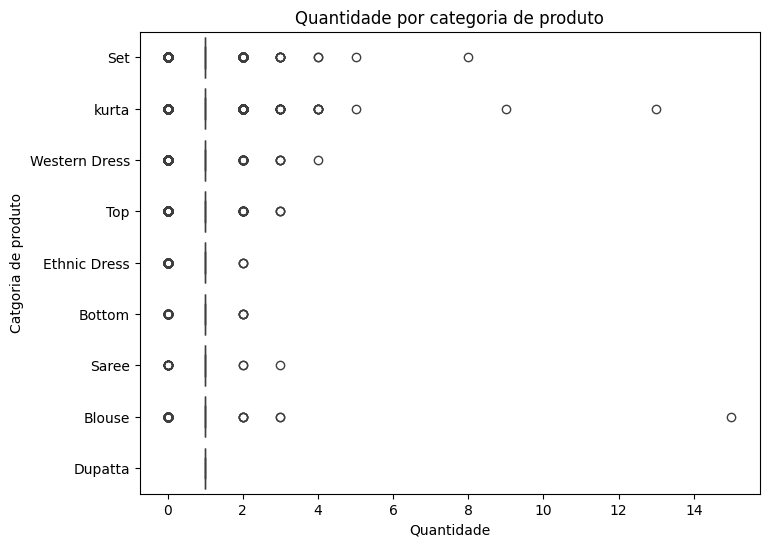

In [901]:
# Boxplot da quantidade de produto por categoria
plt.figure(figsize=(8, 6))
sns.boxplot(x='Qty', y='Category', data=df)
plt.title('Quantidade por categoria de produto')
plt.xlabel('Quantidade')
plt.ylabel('Catgoria de produto')
plt.show()

Este gráfico mostra os boxplots estão achatados próximo do valor 1, o que indica que a grande maioria dos pedidos foram unitários. Pode-se observar outliers com valor 0 em quase todas as categorias, o que não faz sentido em um pedido e esses valores devem ser substituídos por sua mediana. Também se observam outliers com valores maior que 1, mas esses serão mantidos, pois fazem sentido no contexto.

### Valor unitário por categoria


In [902]:
#trocar os valores zerados em Qty por sua mediana
df['Qty'] = df['Qty'].replace(0, df['Qty'].median())

#criar coluna com valor unitário
df['Unit Value'] = df['Amount'] / df['Qty']

# Estatísticas descritivas agrupadas por categoria
df.groupby('Category')['Unit Value'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Blouse,925.0,523.072496,171.709183,0.0,399.050000,545.00,625.0,1266.66
Bottom,440.0,368.904019,126.210242,0.0,301.000000,345.00,379.0,1028.58
Dupatta,3.0,305.000000,0.000000,305.0,305.000000,305.00,305.0,305.00
Ethnic Dress,1158.0,718.313093,257.749386,0.0,475.000000,798.07,855.0,1449.00
Saree,164.0,773.341858,148.891569,0.0,656.397355,790.00,885.0,1248.00
Set,50197.0,819.397698,282.391273,0.0,635.000000,759.00,999.0,4235.72
Top,10611.0,529.720918,143.714045,0.0,460.000000,529.00,621.0,1099.00
Western Dress,15490.0,754.665435,158.209577,0.0,721.000000,744.00,807.0,2259.99
kurta,49783.0,466.169495,147.076895,0.0,376.000000,449.00,523.0,1369.00


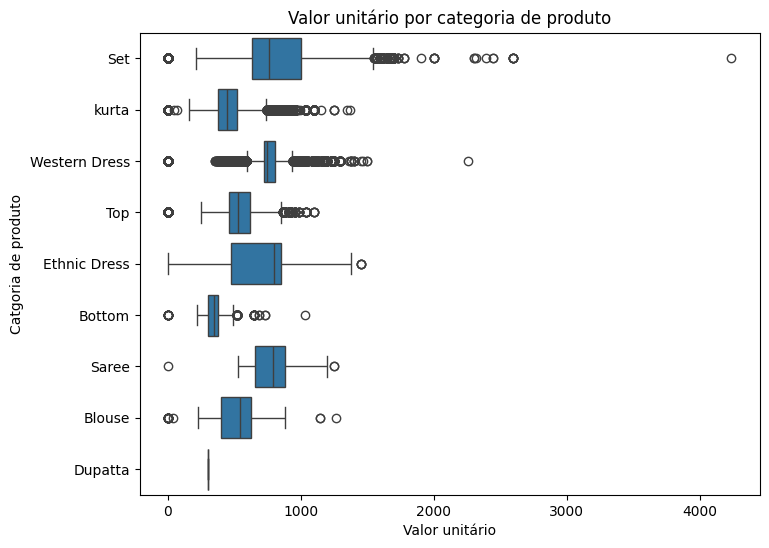

In [903]:
# Boxplot da valor unitário do produto por categoria
plt.figure(figsize=(8, 6))
sns.boxplot(x='Unit Value', y='Category', data=df)
plt.title('Valor unitário por categoria de produto')
plt.xlabel('Valor unitário')
plt.ylabel('Catgoria de produto')
plt.show()

Aqui também pode-se observar outliers com valor 0 em quase todas as categorias, o que não faz sentido em um pedido e esses valores serão ser substituídos por sua média. Entretanto, diferentemente do gráfico anterior, este possui uma maior diversidade de valores.

O boxplot da categoria 'Dupatta' está achatado próximo ao valor 300. Isso significa que não há variação de preço nesse conjunto de dados: ou todos os dupattas registrados custam rigorosamente a mesma quantia, ou a amostra contém o registro de apenas um único produto dessa categoria.

Observando as medianas das outras categorias, percebe-se que as categorias 'Ethnic Dress', 'Set' e 'Saree' possuem as maiores medianas, todas orbitando a faixa de 800. E as categorias 'Bottom' e 'kurta' apresentam as medianas mais baixas, concentrando-se entre 300 e 450.

Observando a largura das caixas, percebe-se que 'Set' e 'Ethnic Dress' têm as caixas mais largas. Isso significa que é possível pode encontrar produtos destas categorias de praticamente qualquer faixa de preço, desde muito baratos até bem caros, sem que isso seja considerado uma anomalia estatística. Já as categorias 'Western Dress' e 'Bottom' possuem caixas muito estreitas. Isso indica que a grande maioria das roupas ocidentais e partes de baixo (bottoms) desta amostra possuem preços muito padronizados.

Observando os outliers, percebe-se que a categoria 'Set' possui os itens mais extremos do gráfico, com diversos outliers se estendendo além de 1500 e chegando a superar a marca de 2500. Isso sugere a presença de conjuntos ('Sets') de luxo ou de marcas premium misturados a itens comuns. Já as categorias 'kurta' e 'Western Dress' possuem uma fileira densa de outliers para a direita, indicando que, embora a maioria seja barata (caixas estreitas à esquerda), há uma grande quantidade de itens dessas categorias sendo vendidos a preços consideravelmente mais altos (chegando a quase 1500).



### Valor total por categoria


In [904]:
# Estatísticas descritivas agrupadas por categoria
df.groupby('Category')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Blouse,925.0,526.826707,172.989039,0.0,418.000000,545.00,625.00,1266.66
Bottom,440.0,371.908565,129.258388,0.0,301.000000,345.00,385.25,1028.58
Dupatta,3.0,305.000000,0.000000,305.0,305.000000,305.00,305.00,305.00
Ethnic Dress,1158.0,719.279414,257.150962,0.0,475.000000,798.07,855.00,1449.00
Saree,164.0,791.286980,200.230332,0.0,656.397355,790.00,885.00,2058.00
Set,50197.0,821.539738,287.414248,0.0,635.000000,759.00,999.00,5584.00
Top,10611.0,531.402004,147.901150,0.0,460.000000,531.00,621.00,1797.00
Western Dress,15490.0,756.872924,165.292640,0.0,721.000000,744.00,807.00,2860.00
kurta,49783.0,468.129260,151.557242,0.0,376.000000,449.00,526.00,2796.00


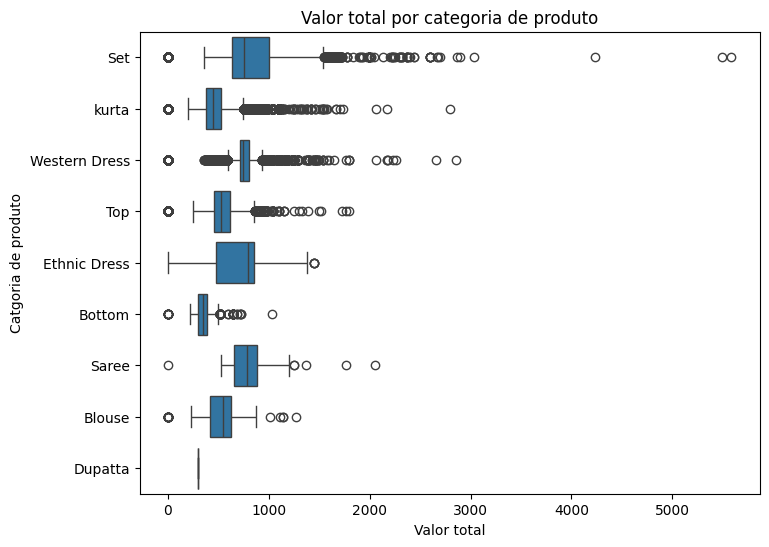

In [905]:
# Boxplot do valor total do produto por categoria
plt.figure(figsize=(8, 6))
sns.boxplot(x='Amount', y='Category', data=df)
plt.title('Valor total por categoria de produto')
plt.xlabel('Valor total')
plt.ylabel('Catgoria de produto')
plt.show()

Os boxplots do gráfico acima quase não possuem alteração em relação ao boxplot 'Valor unitário por categoria de produto' (com exceção de alguns outliers, que agora ultrapassam o valor de 5000 na categoria 'Set'), o que evidencia mais uma vez que a grande maioria dos pedidos neste dataset são unitários.

### Tipo de venda (B2B) por categoria



In [906]:
# Estatísticas descritivas agrupadas por categoria
df.groupby('Category')['B2B'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Blouse,925.0,0.008649,0.092645,0.0,0.0,0.0,0.0,1.0
Bottom,440.0,0.009091,0.095020,0.0,0.0,0.0,0.0,1.0
Dupatta,3.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Ethnic Dress,1158.0,0.012953,0.113122,0.0,0.0,0.0,0.0,1.0
Saree,164.0,0.012195,0.110092,0.0,0.0,0.0,0.0,1.0
Set,50197.0,0.006773,0.082022,0.0,0.0,0.0,0.0,1.0
Top,10611.0,0.005749,0.075606,0.0,0.0,0.0,0.0,1.0
Western Dress,15490.0,0.007295,0.085102,0.0,0.0,0.0,0.0,1.0
kurta,49783.0,0.006589,0.080903,0.0,0.0,0.0,0.0,1.0


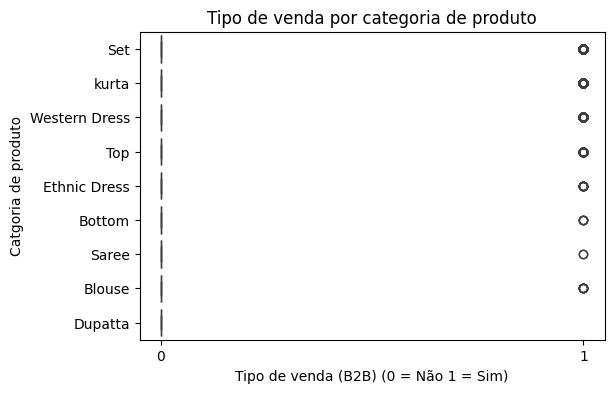

In [907]:
# Boxplot da B2B por categoria
plt.figure(figsize=(6, 4))
sns.boxplot(x='B2B', y='Category', data=df)
plt.title('Tipo de venda por categoria de produto')
plt.xticks([0, 1])
plt.xlabel('Tipo de venda (B2B) (0 = Não 1 = Sim)')
plt.ylabel('Catgoria de produto')
plt.show()

Observa-se que os boxplot de todas as categorias estão achatados próximo do valor 0, o que indica que a grande maioria dos pedidos não são vendas B2B. Todas as categorias, exceto Dupatta, possuem outliers no valor 1, o que indica que essas categorias de produtos tiveram algumas vendas para clientes B2B.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [908]:
#trocar os valores zerados em Qty por sua mediana (1)
df['Amount'] = df['Amount'].replace(0, df['Amount'].mean())

# Matriz de correlação
print("\nMatriz de Correlação:")
df.select_dtypes(include=['number']).corr()


Matriz de Correlação:


,Qty,Amount,B2B,Unit Value
Qty,1.000000,0.115001,0.012425,-0.014517
Amount,0.115001,1.000000,0.012552,0.932859
B2B,0.012425,0.012552,1.000000,0.012191
Unit Value,-0.014517,0.932859,0.012191,1.000000


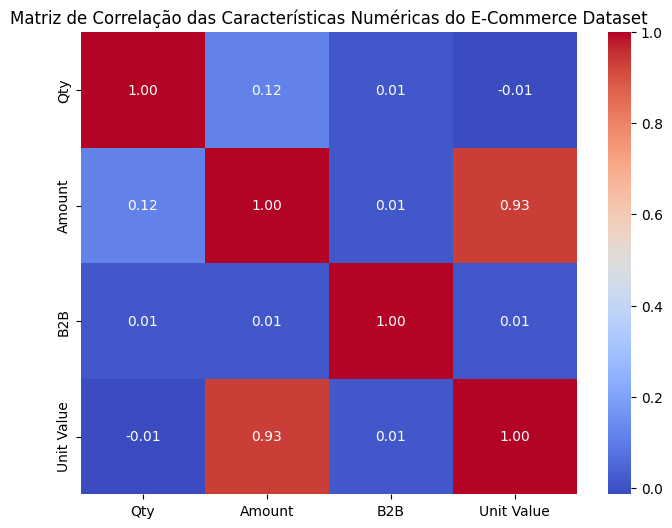

In [909]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do E-Commerce Dataset')
plt.show()

A correlação entre 'Qty' (quantidade) e 'Amount' (valor) é baixa, isso indica que o preço unitário dos produtos varia muito, fazendo com que a quantidade sozinha não explique o valor final.

As correlações entre 'B2B' e os outros atributos também são muito baixas, o que indica que embora existam clientes B2B na base, eles não apresentam um comportamento de compra por atacado. Pode-se comprovar isso no boxplot 'Quantidade por categoria de produto', onde se observa que a grande maioria dos pedidos são unitários, e a maior quantidade de produtos em um mesmo pedido é 15 (outlier).

A correlação entre 'Qty' e 'Unit Value' é muito próxima de zero, o que indica que não existe uma relação linear entre os atributos. Isso ocorre porque a grande maioria dos pedidos neste dataset são unitários, não sendo possível então encontrar uma relação entre o aumento ou diminuição do preço unitário.

Já a correlação entre 'Unit Value' e 'Amount' encontra-se muito próxima de 1, o que indica que se o valor unitário de um produto subir, o valor total do pedido também vai aumentar. Isso já era esperado, já que o valor de 'Amount' é um múltiplo de 'Unit Value'.

# Pré-Processamento de Dados




Para o modelo, alguns atributos do dataset não importam para a previsão. Portanto, eles serão excluídos agora.




In [910]:
df_ppd = df.drop(['Order ID', 'Status', 'Sales Channel ', 'ship-service-level', 'Style', 'Courier Status', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'fulfilled-by'], axis=1, errors='ignore')


## Feature Engineering

Feature Engineering é o ato de transformar dados brutos em formatos que os algoritmos de Machine Learning consigam entender melhor e aprender com mais facilidade. O atributo 'Date' será transformado em novas colunas numéricas para que o modelo de Machine Learning possa entendê-lo.

In [911]:
# extrair informações cruciais para previsão de demanda
df_ppd['Month'] = df_ppd['Date'].dt.month
df_ppd['Week Day'] = df_ppd['Date'].dt.weekday
df_ppd['Month Day'] = df_ppd['Date'].dt.day

# criar uma coluna indicando se é fim de semana (0 ou 1)
df_ppd['Weekend'] = np.where(df_ppd['Week Day'] >= 5, 1, 0)

df_ppd = df_ppd.drop(['Date'], axis=1)

### One Hot Encoding

One-Hot Encoding é uma técnica de Feature Engineering em Machine Learning usada para converter dados categóricos (textos, como nomes de categorias) e numéricos que não possuem hierarquia (número do mês, por exemplo) em dados binários. Usada quando não há hierarquia entre os valores.


In [912]:
# Cria o codificador
encoder = OneHotEncoder(sparse_output=False, dtype=int)

# Treina e transforma apenas as duas colunas
colunas_codificadas = encoder.fit_transform(df_ppd[['Category', 'Size', 'Month', 'Week Day', 'Month Day']])

# Pega os nomes das novas colunas geradas
nomes_novas_colunas = encoder.get_feature_names_out(['Category', 'Size','Month', 'Week Day', 'Month Day'])

# Cria um novo DataFrame com essas colunas de 0 e 1 e junta com o df original
df_encoded = pd.DataFrame(colunas_codificadas, columns=nomes_novas_colunas, index=df.index)
df_ppd = pd.concat([df_ppd.drop(['Category', 'Size', 'Month', 'Week Day', 'Month Day'], axis=1), df_encoded], axis=1)

In [913]:
# Separar features (X) e target (y)
X = df_ppd.drop('Qty', axis=1)
y = df_ppd['Qty']


In [914]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [915]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (90139, 64)
Dimensões de X_test: (38632, 64)
Dimensões de y_train: (90139,)
Dimensões de y_test: (38632,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [916]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()



In [917]:
#atributos numéricos de X_train
X_train_num = X_train[1:]

# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)


In [918]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [919]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   B2B  Unit Value  Weekend  Category_Blouse  Category_Bottom  \
0  0.0    0.258280      1.0              0.0              0.0   
1  0.0    0.157234      1.0              0.0              0.0   
2  0.0    0.153124      1.0              0.0              0.0   
3  0.0    0.122057      1.0              0.0              0.0   
4  0.0    0.228296      0.0              0.0              0.0   

   Category_Dupatta  Category_Ethnic Dress  Category_Saree  Category_Set  \
0               0.0                    0.0             0.0           1.0   
1               0.0                    0.0             0.0           0.0   
2               0.0                    0.0             0.0           0.0   
3               0.0                    0.0             0.0           0.0   
4               0.0                    0.0             0.0           0.0   

   Category_Top  ...  Month Day_22  Month Day_23  Month Day_24  Month Day_25  \
0           0.0  ..

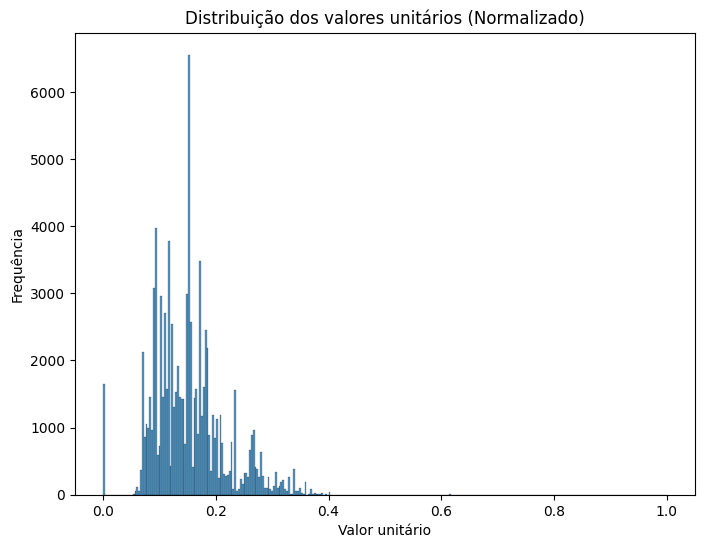

In [920]:
# Visualização da distribuição após a normalização
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Unit Value'])
plt.title('Distribuição dos valores unitários (Normalizado)')
plt.xlabel('Valor unitário')
plt.ylabel('Frequência')
plt.show()

O histograma de Unit Value após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original (verificar histograma de 'Amount' e correlação entre 'Amount' e 'Unit Value').

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [921]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [922]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [923]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [924]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
       B2B  Unit Value   Weekend  Category_Blouse  Category_Bottom  \
0 -0.08117    1.664750  1.544507         -0.08423        -0.057204   
1 -0.08117    0.072354  1.544507         -0.08423        -0.057204   
2 -0.08117    0.007577  1.544507         -0.08423        -0.057204   
3 -0.08117   -0.482008  1.544507         -0.08423        -0.057204   
4 -0.08117    1.192240 -0.647456         -0.08423        -0.057204   

   Category_Dupatta  Category_Ethnic Dress  Category_Saree  Category_Set  \
0               0.0              -0.095224       -0.035585      1.253217   
1               0.0              -0.095224       -0.035585     -0.797946   
2               0.0              -0.095224       -0.035585     -0.797946   
3               0.0              -0.095224       -0.035585     -0.797946   
4               0.0              -0.095224       -0.035585     -0.797946   

   Category_Top  ...  Month Day_22  Month Day_23  Month Day_24  Month

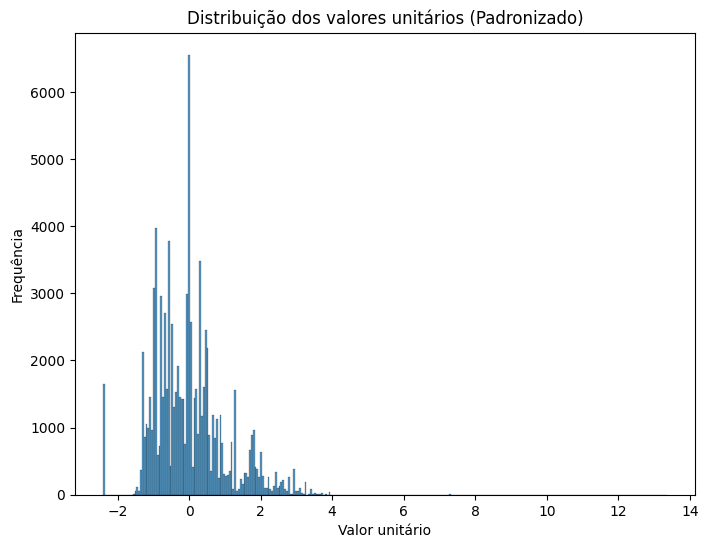

In [925]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Unit Value'])
plt.title('Distribuição dos valores unitários (Padronizado)')
plt.xlabel('Valor unitário')
plt.ylabel('Frequência')
plt.show()

O histograma de 'Unit Value' após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

# Respondendo nossas hipóteses



## Hipótese 1: A categoria de produtos mais vendidos é o sari (saree)?

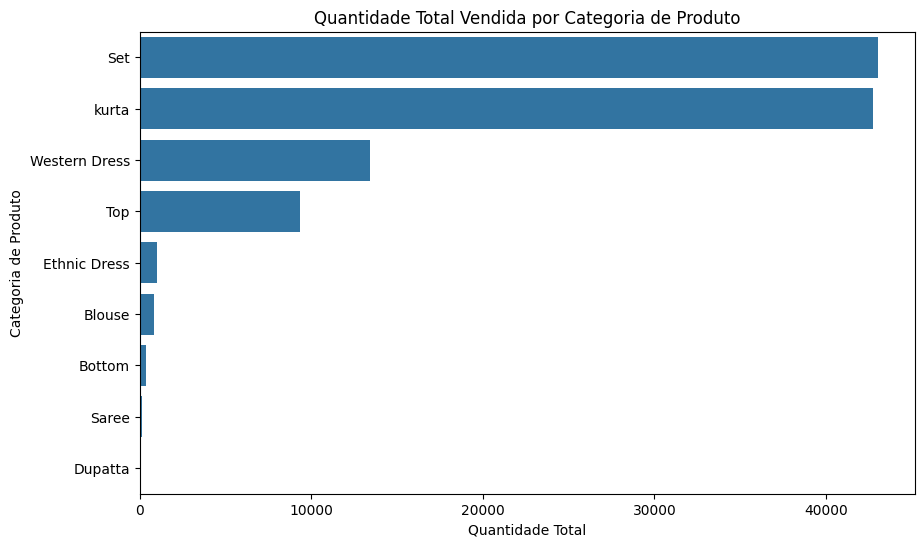

In [926]:
# considerar somente as vendas não canceladas
df_nc = df[df['Status'] != 'Cancelled']

# plotar gráfico categoria vs quantidade
df_nc_cat = df_nc.groupby('Category')['Qty'].sum().reset_index()
df_nc_cat = df_nc_cat.sort_values(by='Qty', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Qty',
    y='Category',
    data=df_nc_cat,
)
plt.title('Quantidade Total Vendida por Categoria de Produto')
plt.xlabel('Quantidade Total')
plt.ylabel('Categoria de Produto')
plt.show()


Como verificado no gráfico acima, a categoria 'Saree' não é a mais vendida. Na verdade, ela está entre as menos vendidas. A categoria mais vendida é o 'Set', que pode ser um conjunto de blusa/saia ou tunica/calça.

## Hipótese 2: Os maiores pedidos são feitos por empresas (vendas B2B)?

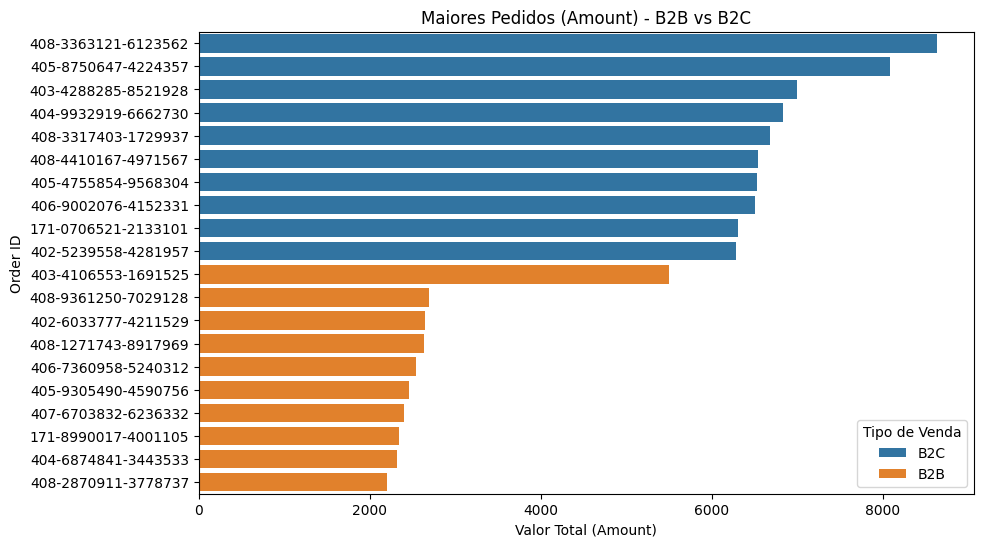

In [927]:
# agrupar os pedidos B2C e pegar os 10 maiores pedidos B2C
top_10_b2c = df_nc[df_nc['B2B'] == 0].groupby('Order ID')
top_10_b2c = top_10_b2c['Amount'].sum().reset_index().nlargest(10, 'Amount')
top_10_b2c['client type'] = 'B2C'

# agrupar os pedidos B2B e pegar os 10 maiores pedidos B2B
top_10_b2b = df_nc[df_nc['B2B'] == 1].groupby('Order ID')
top_10_b2b = top_10_b2b['Amount'].sum().reset_index().nlargest(10, 'Amount')
top_10_b2b['client type'] = 'B2B'

#concatenar os dfs e ordenar por valor
df_top_combinado = pd.concat([top_10_b2c, top_10_b2b])
df_top_combinado = df_top_combinado.sort_values(by='Amount', ascending=False)

# plotar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_top_combinado,
    x='Amount',
    y='Order ID',
    hue='client type',       # Colore as barras baseado se é 0 ou 1
    dodge=False,     # Evita que o gráfico deixe "buracos" entre as barras
    #palette={0: '#3274A1', 1: '#E1812C'} # Azul para 0, Laranja para 1
)

plt.title('Maiores Pedidos (Amount) - B2B vs B2C')
plt.xlabel('Valor Total (Amount)')
plt.ylabel('Order ID')
plt.legend(title='Tipo de Venda')
plt.show()


Baseado no gráfico acima, pode-se comprovar que os maiores pedidos de venda não foram realizados por vendas B2B.

## Hipótese 3: O cancelamento dos pedidos está relacionado com o método de entrega?

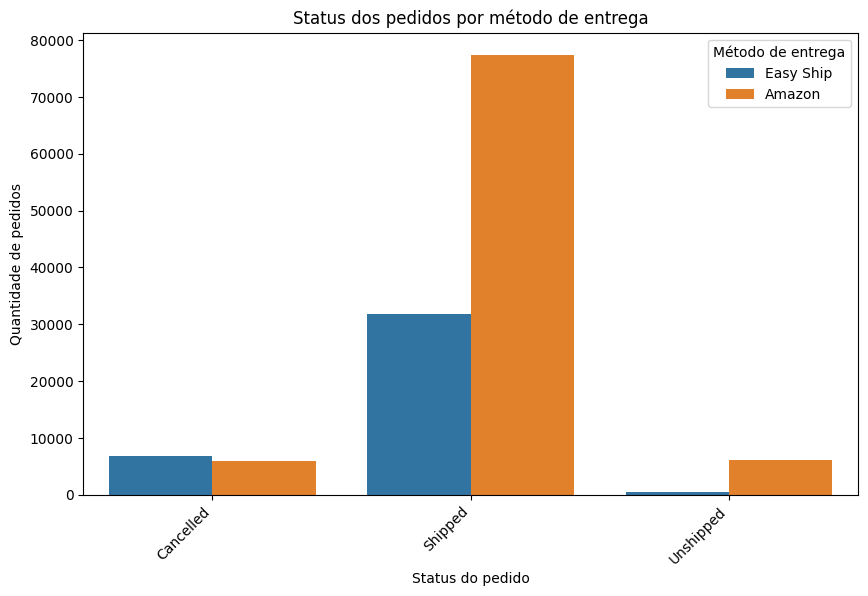

In [928]:
# plotar gráfico de status do pedido vs método de entrega
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Courier Status',
    hue='fulfilled-by'
)
plt.title('Status dos pedidos por método de entrega')
plt.xlabel('Status do pedido')
plt.ylabel('Quantidade de pedidos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de entrega')
plt.show()

Verifica-se pelo gráfico acima que a quantidade de pedidos cancelados são semelhantes para os dois métodos de entrega, via Amazon ou via Easy Ship. Portanto, não se pode afirmar que o método de entrega está relacionado com o cancelamento.

# Conclusão

O objetivo central deste MVP foi estruturar e preparar um fluxo de dados para futuramente desenvolver um modelo preditivo capaz de estimar a quantidade futura de vendas ('Qty'). A base passou por um rigoroso processo de limpeza, codificação de categorias (One-Hot Encoding) e Engenharia de Recursos (Feature Engineering) focada em sazonalidade, garantindo que o algoritmo pudesse ler os padrões temporais.

Durante a fase de análise exploratória, foi possível identificar alguns padrões:

1. Comportamento do Portfólio: Categorias como 'Set' e 'Ethnic Dress' abrigam a maior variação de preços e os itens mais caros (outliers expressivos), enquanto categorias como 'Western Dress' possuem uma precificação altamente padronizada.

2. Perfil do Canal de Vendas: A esmagadora maioria do volume financeiro e de pedidos advém do consumidor final (B2C). As vendas B2B, embora representem tickets isolados altos, são estatisticamente raras na operação atual.


As três hipóteses levantadas foram validadas:

1.   *A categoria de produtos mais vendidos é o sari (saree)?* Não, a categoria mais vendida é a 'Set'.
2.   *Os maiores pedidos são feitos por empresas (vendas B2B)?* Não, os maiores pedidos foram vendas B2C.

3.   *O cancelamento dos pedidos está relacionado com o método de entrega?* Não se pode afirmar que o método de entrega impacta o cancelamento dos pedidos.